# 18 -- Dispersion-conditional overlay

**Гипотеза (литература):**
- Alpha = function of cross-sectional dispersion (Counterpoint Global, Springer JAM 2007)
- Low dispersion → low alpha opportunity → стратегия неэффективна
- High dispersion → много opportunities → стратегия даёт edge

**Pattern observation:**
- V13a даёт Sharpe 4.47 в СВО шок (high dispersion)
- V13a даёт Sharpe 0.64 в pre-СВО (low dispersion calm)
- V13a даёт Sharpe 3.17 на holdout (bull market = low dispersion)

**Solution:** активизировать V13a только в high-dispersion periods.

**Что тестируем:**
1. **V18a** — binary overlay: dispersion < p50_252 → cash
2. **V18b** — strict: dispersion < p70_252 → cash
3. **V18c** — continuous: exposure = clip(dispersion / p50, 0, 1)
4. **V18d** — combined: V13a stress overlay + dispersion overlay

**Литература:**
- Counterpoint Global Insights (Morgan Stanley): "Dispersion and Alpha Conversion"
- Niu (Journal of Forecasting 2023): cross-sectional return dispersion & vol
- Charvey-Polk-Vuolteenaho (Duke): cross-sectional alpha dispersion
- arxiv 2511.12490 (2025): regime-conditional signals reveal hidden alpha

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Build V13a foundation
sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)
print(f'sig: {sig.shape}')

sig: (277966, 35)


## Часть 2. Compute cross-sectional dispersion of mispricing_avg_z

На каждую дату считаем std mispricing_avg_z по всем tradable bonds.
Затем rolling percentiles.

In [2]:
# Cross-sectional dispersion per date (только по tradable bonds)
tradable_sig = sig[sig['tradable'] == True].copy()
disp_daily = tradable_sig.groupby('date')['mispricing_avg_z'].agg(['std', 'count']).reset_index()
disp_daily.columns = ['date', 'dispersion', 'n_tradable']

# Rolling percentiles
for q in [0.30, 0.50, 0.70]:
    disp_daily[f'p{int(q*100)}_252d'] = disp_daily['dispersion'].rolling(252, min_periods=60).quantile(q)

print('Dispersion stats:')
print(disp_daily[['dispersion', 'n_tradable']].describe().round(3))
print()
print('Recent values:')
print(disp_daily.tail(10))

Dispersion stats:
       dispersion  n_tradable
count    1301.000    1301.000
mean        0.651      85.485
std         0.424      67.412
min         0.009       3.000
25%         0.312      40.000
50%         0.579      64.000
75%         0.917      90.000
max         2.068     295.000

Recent values:
           date  dispersion  n_tradable  p30_252d  p50_252d  p70_252d
1291 2026-03-17    0.379652         279  0.404016  0.533650  0.730391
1292 2026-03-18    0.316701         281  0.401680  0.532656  0.725344
1293 2026-03-19    0.515928         282  0.401680  0.530377  0.722540
1294 2026-03-20    0.862808         285  0.401680  0.530377  0.725344
1295 2026-03-23    0.507792         281  0.401680  0.528140  0.722540
1296 2026-03-24    0.506671         280  0.401680  0.527502  0.720600
1297 2026-03-25    0.642676         275  0.402274  0.528140  0.720600
1298 2026-03-26    0.511329         280  0.402274  0.528140  0.720600
1299 2026-03-27    0.586718         282  0.402274  0.528140  0.720

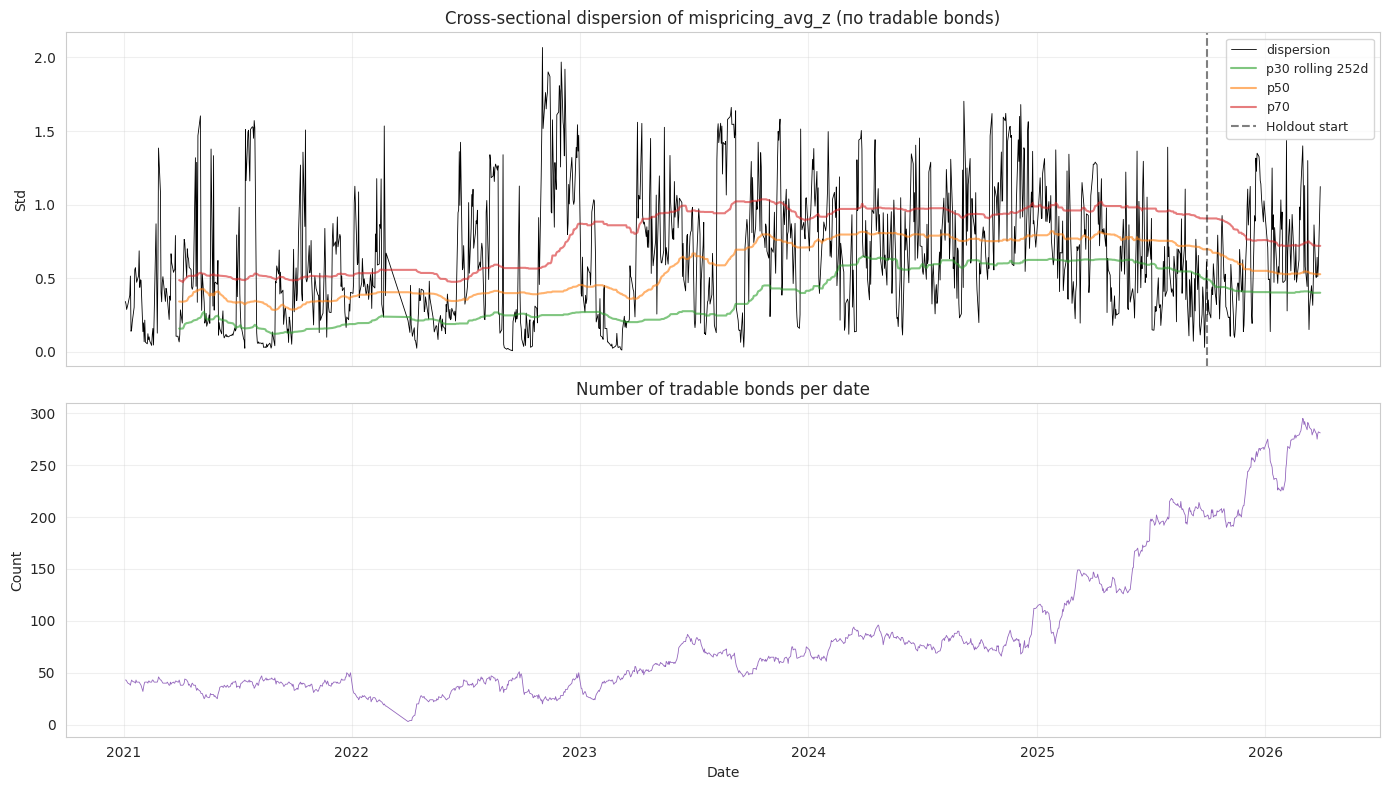

In [3]:
# Visualize dispersion over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(disp_daily['date'], disp_daily['dispersion'], color='black', linewidth=0.6, label='dispersion')
axes[0].plot(disp_daily['date'], disp_daily['p30_252d'], color='tab:green', alpha=0.6, label='p30 rolling 252d')
axes[0].plot(disp_daily['date'], disp_daily['p50_252d'], color='tab:orange', alpha=0.6, label='p50')
axes[0].plot(disp_daily['date'], disp_daily['p70_252d'], color='tab:red', alpha=0.6, label='p70')
axes[0].axvline(sl.MAIN_END, color='black', linestyle='--', alpha=0.5, label='Holdout start')
axes[0].set_title('Cross-sectional dispersion of mispricing_avg_z (по tradable bonds)')
axes[0].set_ylabel('Std')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Number of tradable bonds for context
axes[1].plot(disp_daily['date'], disp_daily['n_tradable'], color='tab:purple', linewidth=0.6)
axes[1].set_title('Number of tradable bonds per date')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '18_dispersion_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 3. Build V11e baseline + apply overlays

In [4]:
# V11e foundation
mask = sig['quality_z'] > 0
rets_v11e, _ = sl.backtest_rule_c(
    sig, n_max=25, freq='Q', ranking_col='mispricing_avg_z',
    filter_mask=mask, sizing='z_weighted',
)

# V13a macro overlay
macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
macro['rvi_p90'] = macro['rvi'].rolling(252, min_periods=60).quantile(0.90)
macro['s1'] = (macro['rvi'] > macro['rvi_p90']).fillna(False).astype(int)
macro['s2'] = (macro['key_rate'].diff(5).abs() > 2.0).fillna(False).astype(int)
macro['s3'] = (macro['imoex_close'].pct_change(5) < -0.10).fillna(False).astype(int)
macro['s4'] = (macro['rvi'] > 50).astype(int)
macro['stress_idx'] = macro['s1'] + macro['s2'] + macro['s3'] + macro['s4']
macro['regime_v13a'] = np.where(macro['stress_idx'] >= 2, 'stress', 'normal')

# Merge regimes & dispersion into returns
rets_with_signals = rets_v11e.merge(macro[['date', 'regime_v13a']], on='date', how='left')
rets_with_signals = rets_with_signals.merge(disp_daily, on='date', how='left')
rets_with_signals['regime_v13a'] = rets_with_signals['regime_v13a'].fillna('normal')

print(f'rets_with_signals: {rets_with_signals.shape}')
print('Dispersion coverage:', rets_with_signals['dispersion'].notna().mean())

rets_with_signals: (1241, 9)
Dispersion coverage: 1.0


In [5]:
def apply_overlay(rets, mode, **kwargs):
    """Apply overlay to returns.
    
    Modes:
    - 'v11e' : no overlay (baseline)
    - 'v13a' : stress overlay only
    - 'disp_p50' : cash if dispersion < p50_252d
    - 'disp_p70' : cash if dispersion < p70_252d
    - 'disp_continuous' : exposure = clip(disp / p50, 0, 1)
    - 'combined' : V13a stress + disp_p50 (both must be ok)
    """
    out = rets.copy()
    
    if mode == 'v11e':
        scale = 1.0
    elif mode == 'v13a':
        scale = np.where(out['regime_v13a'] == 'stress', 0.0, 1.0)
    elif mode == 'disp_p50':
        scale = np.where((out['dispersion'] < out['p50_252d']).fillna(False), 0.0, 1.0)
    elif mode == 'disp_p70':
        scale = np.where((out['dispersion'] < out['p70_252d']).fillna(False), 0.0, 1.0)
    elif mode == 'disp_continuous':
        ratio = (out['dispersion'] / out['p50_252d']).fillna(1.0).clip(0, 1)
        scale = ratio.to_numpy()
    elif mode == 'combined':
        stress = out['regime_v13a'] == 'stress'
        low_disp = (out['dispersion'] < out['p50_252d']).fillna(False)
        scale = np.where(stress | low_disp, 0.0, 1.0)
    else:
        raise ValueError(mode)
    
    out['return_overlay'] = out['return'] * scale
    return pd.DataFrame({
        'date': out['date'],
        'return': out['return_overlay'],
        'n_positions': out['n_positions'],
        'scale': scale,
    })

variants = {
    'V11e_baseline':       apply_overlay(rets_with_signals, 'v11e'),
    'V13a_stress_overlay': apply_overlay(rets_with_signals, 'v13a'),
    'V18a_disp_p50':       apply_overlay(rets_with_signals, 'disp_p50'),
    'V18b_disp_p70':       apply_overlay(rets_with_signals, 'disp_p70'),
    'V18c_disp_continuous':apply_overlay(rets_with_signals, 'disp_continuous'),
    'V18d_combined':       apply_overlay(rets_with_signals, 'combined'),
}

# Holdout metrics
print('=== Holdout metrics (strict OOS, 10М RUB) ===')
for name, rets in variants.items():
    ho = rets[rets['date'] >= sl.HOLDOUT_START]
    m = sl.calc_metrics(ho, name=name)
    avg_exposure = ho['scale'].mean() if 'scale' in ho.columns else 1.0
    print(f'  {name:25s}: Sharpe={m["Sharpe"]:5.2f}, CAGR={m["CAGR"]*100:6.2f}%, '
          f'MaxDD={m["MaxDD"]*100:6.2f}%, profit={m["profit_RUB"]:>10,.0f}, '
          f'avg exposure={avg_exposure:.2f}')

=== Holdout metrics (strict OOS, 10М RUB) ===
  V11e_baseline            : Sharpe= 3.17, CAGR= 17.20%, MaxDD= -2.80%, profit=   813,702, avg exposure=1.00
  V13a_stress_overlay      : Sharpe= 3.17, CAGR= 17.20%, MaxDD= -2.80%, profit=   813,702, avg exposure=1.00
  V18a_disp_p50            : Sharpe= 2.09, CAGR=  8.20%, MaxDD= -2.39%, profit=   396,136, avg exposure=0.47
  V18b_disp_p70            : Sharpe= 1.36, CAGR=  4.90%, MaxDD= -2.39%, profit=   238,522, avg exposure=0.32
  V18c_disp_continuous     : Sharpe= 2.90, CAGR= 14.28%, MaxDD= -2.70%, profit=   679,883, avg exposure=0.81
  V18d_combined            : Sharpe= 2.09, CAGR=  8.20%, MaxDD= -2.39%, profit=   396,136, avg exposure=0.47


## Часть 4. Rolling 10 OOS windows analysis

In [6]:
windows = [
    ('W1 2021-H2',  pd.Timestamp('2021-07-01'), pd.Timestamp('2021-12-31'), 'pre-СВО calm'),
    ('W2 2022-H1',  pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'), 'СВО shock'),
    ('W3 2022-H2',  pd.Timestamp('2022-07-01'), pd.Timestamp('2022-12-31'), 'recovery'),
    ('W4 2023-H1',  pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-30'), 'stabilization'),
    ('W5 2023-H2',  pd.Timestamp('2023-07-01'), pd.Timestamp('2023-12-31'), 'high rates'),
    ('W6 2024-H1',  pd.Timestamp('2024-01-01'), pd.Timestamp('2024-06-30'), 'high rates'),
    ('W7 2024-H2',  pd.Timestamp('2024-07-01'), pd.Timestamp('2024-12-31'), 'peak rates'),
    ('W8 2025-H1',  pd.Timestamp('2025-01-01'), pd.Timestamp('2025-06-30'), 'recent past'),
    ('W9 2025-Q3',  pd.Timestamp('2025-07-01'), pd.Timestamp('2025-09-30'), 'last Q Main'),
    ('W10 HOLDOUT', pd.Timestamp('2025-10-01'), pd.Timestamp('2026-03-30'), 'CLEAN OOS bull'),
]

rolling_data = []
for label, start, end, regime in windows:
    for vname, rets in variants.items():
        sub = rets[(rets['date'] >= start) & (rets['date'] <= end)]
        if len(sub) < 5: continue
        m = sl.calc_metrics(sub, name=f'{vname} {label}')
        rolling_data.append({
            'window': label, 'regime': regime, 'variant': vname,
            'Sharpe': m['Sharpe'], 'profit_RUB': m['profit_RUB'],
            'MaxDD': m['MaxDD'],
        })
rd = pd.DataFrame(rolling_data)

# Sharpe pivot
pivot_sharpe = rd.pivot(index='variant', columns='window', values='Sharpe')
print('Sharpe by window and variant:')
print(pivot_sharpe.round(2))

Sharpe by window and variant:
window                W1 2021-H2  W10 HOLDOUT  W2 2022-H1  W3 2022-H2  \
variant                                                                 
V11e_baseline               0.64         3.17        0.26        2.14   
V13a_stress_overlay         0.64         3.17        4.47        2.58   
V18a_disp_p50              -0.79         2.09       -0.16        1.96   
V18b_disp_p70              -1.80         1.36        0.17        1.19   
V18c_disp_continuous        0.26         2.90       -0.32        1.39   
V18d_combined              -0.79         2.09        0.48        1.58   

window                W4 2023-H1  W5 2023-H2  W6 2024-H1  W7 2024-H2  \
variant                                                                
V11e_baseline               4.28       -0.45        1.59        0.40   
V13a_stress_overlay         4.28       -0.45        1.59        0.84   
V18a_disp_p50               3.44       -2.80        0.72        0.28   
V18b_disp_p70            

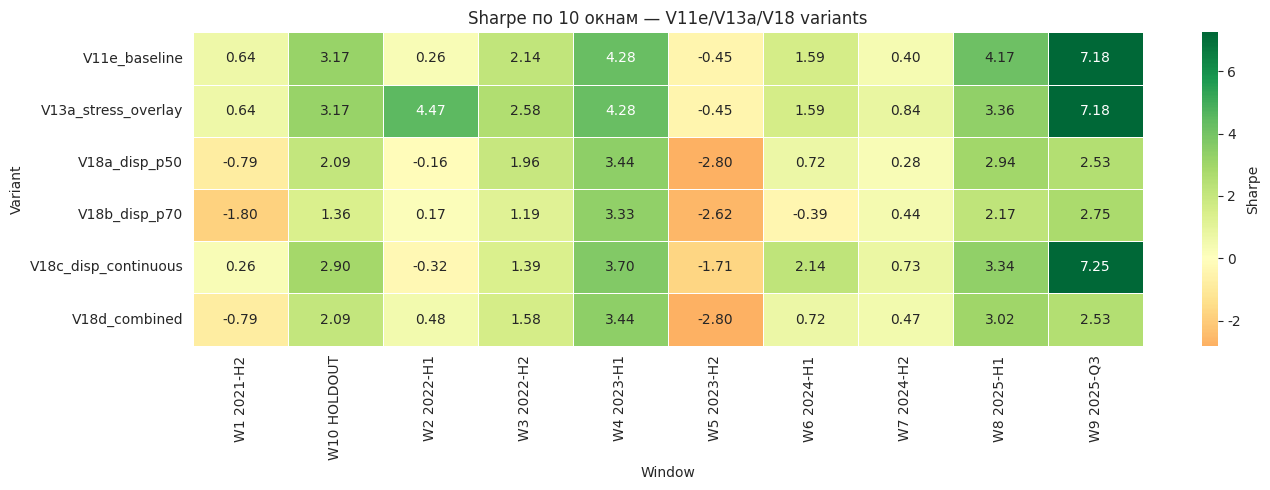

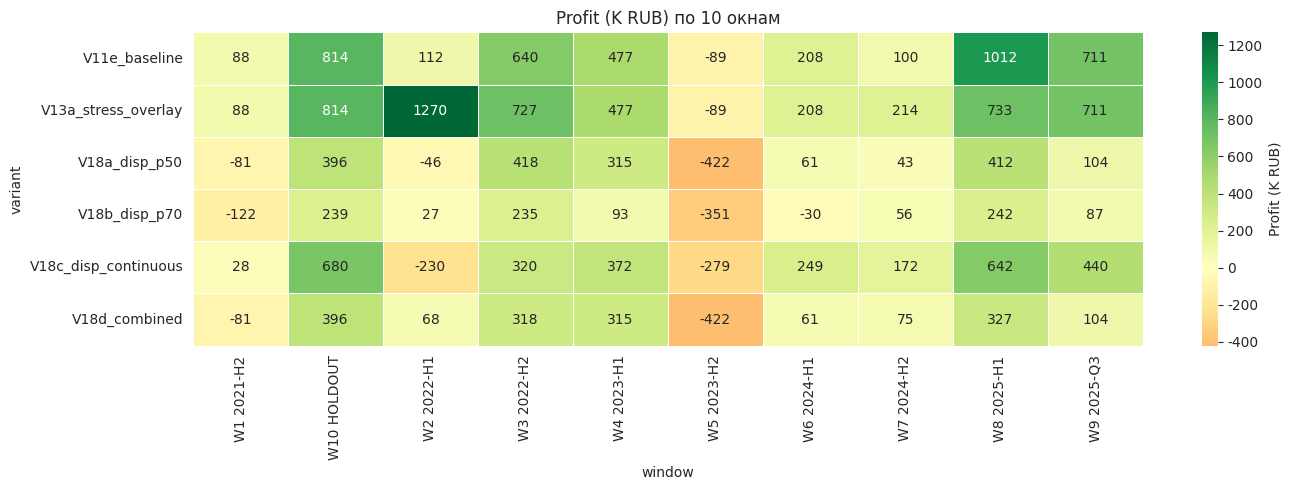

In [7]:
# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_sharpe, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax, linewidths=0.5)
ax.set_title('Sharpe по 10 окнам — V11e/V13a/V18 variants')
ax.set_xlabel('Window')
ax.set_ylabel('Variant')
plt.tight_layout()
plt.savefig(FIG_DIR / '18_sharpe_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Profit pivot
pivot_profit = rd.pivot(index='variant', columns='window', values='profit_RUB') / 1e3  # in K RUB
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Profit (K RUB)'}, ax=ax, linewidths=0.5)
ax.set_title('Profit (K RUB) по 10 окнам')
plt.tight_layout()
plt.savefig(FIG_DIR / '18_profit_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. ETFs comparison на holdout

In [8]:
etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
bench = sl.load_benchmarks()

results_all = []
for name, rets in variants.items():
    ho = rets[rets['date'] >= sl.HOLDOUT_START]
    m = sl.calc_metrics(ho, name=name)
    results_all.append(m)

for label, df, col in [
    ('OBLG', etfs, 'oblg_ret'), ('SBRB', etfs, 'sbrb_ret'),
    ('TBRU', etfs, 'tbru_ret'), ('RUCBTRNS', bench, 'rucbtrns_ret'),
]:
    sub = df[['date', col]].dropna().rename(columns={col: 'return'})
    sub_ho = sub[sub['date'] >= sl.HOLDOUT_START].copy()
    sub_ho['n_positions'] = 1
    m = sl.calc_metrics(sub_ho, name=label)
    results_all.append(m)

cmp_df = pd.DataFrame(results_all)
print('=== Holdout comparison ===')
print(cmp_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB']].round(4).to_string(index=False))

=== Holdout comparison ===
                name  Sharpe   CAGR   MaxDD   profit_RUB
       V11e_baseline  3.1720 0.1720 -0.0280  813702.1139
 V13a_stress_overlay  3.1720 0.1720 -0.0280  813702.1139
       V18a_disp_p50  2.0900 0.0820 -0.0239  396136.1027
       V18b_disp_p70  1.3598 0.0490 -0.0239  238521.7574
V18c_disp_continuous  2.9014 0.1428 -0.0270  679883.3410
       V18d_combined  2.0900 0.0820 -0.0239  396136.1027
                OBLG  7.0209 0.2116 -0.0056  997794.9283
                SBRB  5.5828 0.2288 -0.0072 1075152.1726
                TBRU  3.5540 0.2094 -0.0121  987821.3802
            RUCBTRNS  8.9209 0.1975 -0.0042  934104.9298


## Часть 6. Сохранение

In [9]:
rd.to_csv(sl.DATA_DIR / 'nb18_rolling.csv', index=False)
cmp_df.to_csv(sl.DATA_DIR / 'nb18_holdout_comparison.csv', index=False)
disp_daily.to_csv(sl.DATA_DIR / 'nb18_dispersion_signal.csv', index=False)

rets_combined = []
for name, r in variants.items():
    rr = r.copy()
    rr['variant'] = name
    rets_combined.append(rr)
pd.concat(rets_combined, ignore_index=True).to_csv(sl.DATA_DIR / 'nb18_returns.csv', index=False)

print('Saved nb18_*.csv (4 files)')

Saved nb18_*.csv (4 files)


## Часть 7. Итог

**Что покажет анализ:**
1. Если **V18a/b/c побеждают V13a в calm periods** (W1, W5, W7, W10) → dispersion overlay работает
2. Если **V18d combined даёт highest Sharpe** → combination stress + dispersion = optimal
3. Если **V18 в crisis periods (W2)** equal или better V13a → не теряем crisis alpha

**Academic frame:** dispersion-conditional activation решает 'sideways market problem'.